# Elaborado por: Alexis Gael Hilario Velázquez

In [1]:
import math as mt
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 1: Grafica de datos experimentales

a) Escribe un programa que lea los datos y haga una grafica de las manchas solares  ́  en funcion del tiempo.  ́

In [2]:
#Exportamos los datos de archivo manchasolares.txt
Manchas = np.loadtxt("manchasolares.txt", float)

In [4]:
Tiempo = []#Creo 2 listas vacías para separar los valores de tiempo y manchas solares
Solares = [] 
for i in range(0,len(Manchas)):
    Tiempo.append(Manchas[i,0])  #el primer elemento de cada entrada de manchas es el tiempo, entonces lo agregamos a Tiempo
    Solares.append(Manchas[i,1]) #el segundo elemento de cada entrada de manchas son manchas solares, entonces lo agregamos en Solares

In [6]:
Tiempo = np.array(Tiempo, int) #Convertimos en arreglos de numpy a cada uno

In [7]:
Solares = np.array(Solares, float)

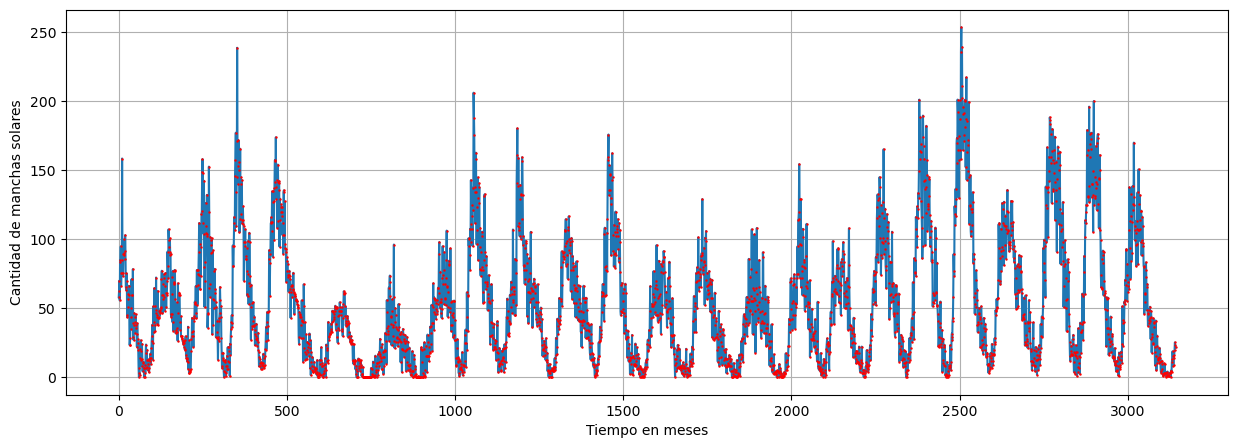

In [12]:
plt.figure(figsize=(15,5)) #definimos el largo y ancho de la figura
plt.plot(Tiempo, Solares) #graficamos la función con lineas
plt.plot(Tiempo,Solares, 'r.', ms = 1.5) #agregamos puntos en cada pico de nuestra función.
plt.grid()
plt.ylabel("Cantidad de manchas solares")
plt.xlabel("Tiempo en meses")
plt.show()


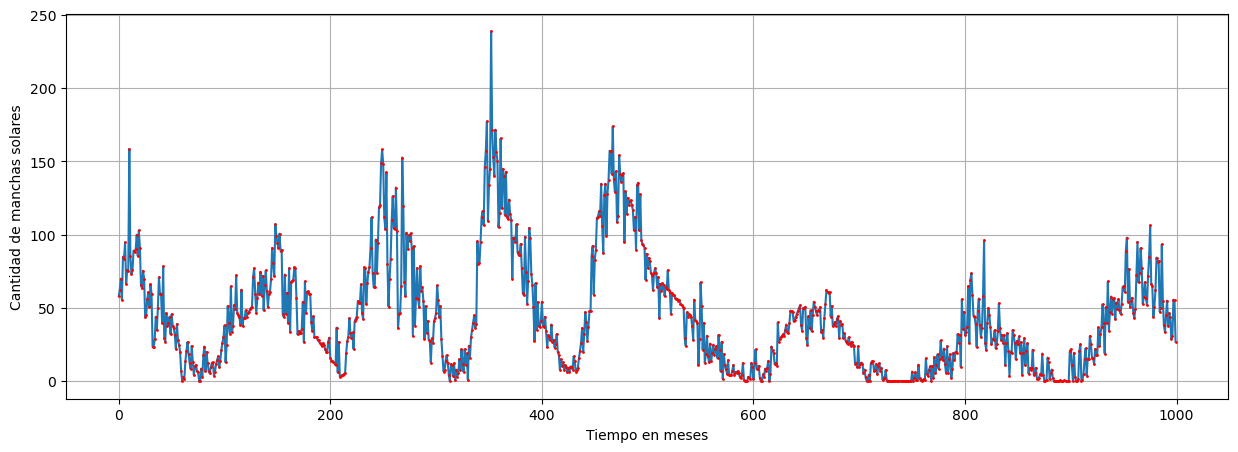

In [13]:
# queremos solo los primeros mil datos
n = 1000 #numero de datos que queremos ver
plt.figure(figsize=(15,5)) 
plt.plot(Tiempo[:n], Solares[:n]) #solo acortamos los arreglos con [:n]
plt.plot(Tiempo[:n], Solares[:n], 'r.', ms = 2)
plt.ylabel("Cantidad de manchas solares")
plt.xlabel("Tiempo en meses")
plt.grid()
plt.show()

In [10]:
#Calcular la media movil
mediam= [] #guardamos los valores de media móvil.
r=5 #fijamos una r
for i in range(0,n): #planteamos una iteración de 0 a n que en celdas pasadas es 1000.
    mm = 0 #definimos un valor mm que guardará nuestros valores de la suma
    for j in range(-r,r+1): #un for que nos ayudará con la suma de -r a r
        if i+j < 0: #si la suma de ambos indices es menor que 0, se los salta
            continue
        mm += Solares[i+j] #para todas las demás condiciones mm es la suma de Solares[i+j]
    mm = mm/(2*r+1) #despues de que haga todas las sumas que multiplique por el factor 1/(2*r+1) dado por la fórmula de la tarea.
    mediam.append(mm) #y lo agregamos a la lista de la mediam que son los valores de la media móvil
    


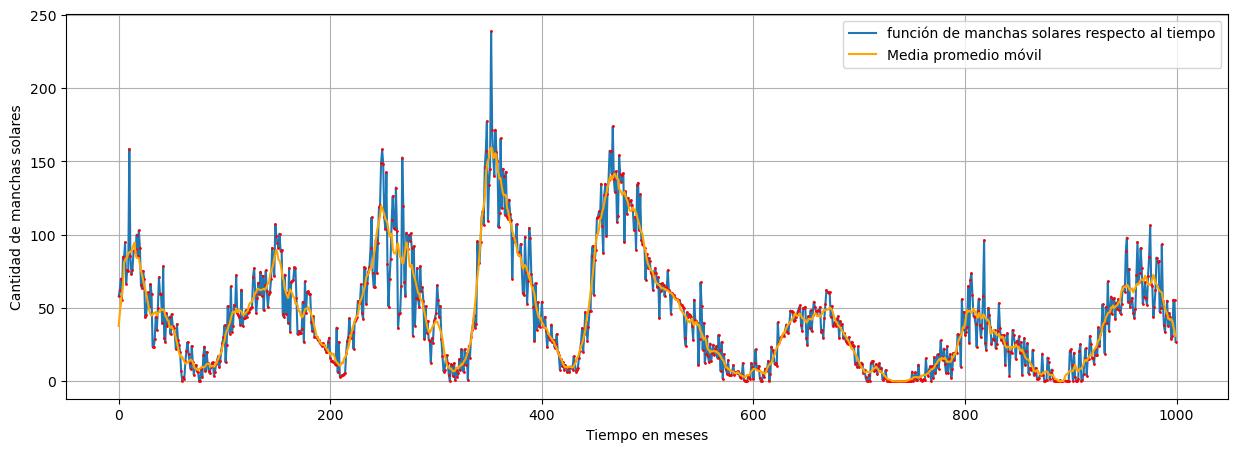

In [14]:
n = 1000 #numero de datos que queremos ver
plt.figure(figsize=(15,5)) 
plt.plot(Tiempo[:n], Solares[:n], label= "función de manchas solares respecto al tiempo")
plt.plot(Tiempo[:n], Solares[:n], 'r.', ms = 2)
plt.plot(Tiempo[:n], mediam, ms =2, color = 'orange', label= "Media promedio móvil") 
plt.ylabel("Cantidad de manchas solares")
plt.xlabel("Tiempo en meses")
plt.grid()
plt.legend()
plt.show()

## Ejercicio 2: La gráfica de Feigenbaum (caos determinista)

a) Apoyate en el programa que vimos en clase y escribe un programa que muestre
el comportamiento del mapeo logístico mediante una gráfica.  

In [15]:
r = 2 #fijamos una r 
P_0=0.9 #un valor de inicio
N = 100 #la cantidad de veces de interaciones
X_n = []
for n in range(N):
    X_n.append(P_0)
    P_0 = r*P_0 - r*P_0**2

0.5


In [17]:
Tiempo= [i for i in range(N)] #creo una lista llamada tiempo (que es la cantidad de iteraciones pero en una lista)

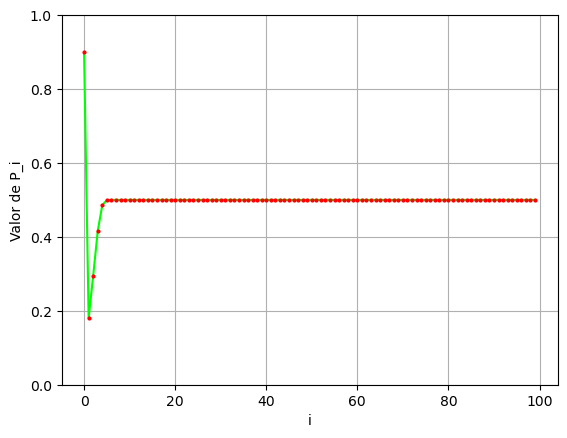

In [21]:
plt.plot(Tiempo, X_n, color = "lime")
plt.plot(Tiempo, X_n, 'ro', ms = 2)
plt.ylabel("Valor de P_i") #valor de P_i donde i es la cantidad de iteración de la ecuación logística para P=0
plt.xlabel("i") #cantidad de iteración
plt.ylim(0,1)
plt.grid()

b) De acuerdo a tu grafica, ¿a que valor de r el sistema pasa de un comportamiento ordenado (puntos fijos o ciclos límite) a un comportamiento caótico? A este punto a veces se le llama “el borde del caos”.

In [22]:
r= np.arange(1,4.01,0.01)

In [30]:
P_0=0.5 #replicamos el mismo codigo solo que ahora tenemos una r que se mueve en tasa
N = 1001 #cantidad de iteraciones 
Convergencia= [] #lista vacía donde agregaremos valores de convergencia
Tasa= np.arange(1,4.01,0.01) 
for r in Tasa: #for que varia el valor de r
    for n in range(N): #for que me genera las N iteraciones de la ecuación logística
        P_0 = r*P_0 - r*P_0**2 
    Convergencia.append(P_0) #solo agrega el ultimo valor P_0 por cada r

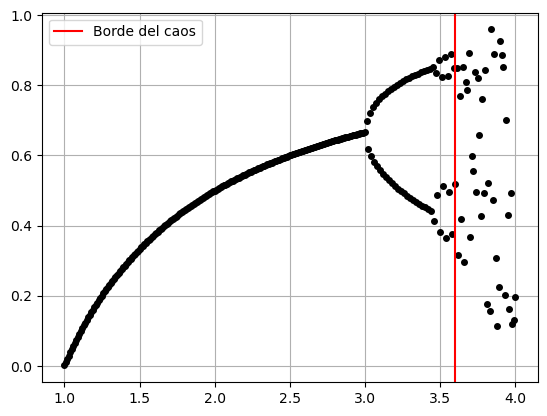

In [45]:
plt.plot(Tasa,Convergencia, 'ko', ms = 4) #grafica r y sus respectivos valores de convergencía
plt.axvline(x = Tasa[260], color = 'r',label = "Borde del caos") #el borde de caos aproximado en la gráfica
plt.grid()
plt.legend()
plt.show()

Un valor aproximado de borde del caos a partir de la gráfica es de Tasa[260] que es aproximadamente a 3.6

In [42]:
Tasa[260]

np.float64(3.6000000000000023)

c) ** Opcional (para 1.5 puntos extra): Hay otra forma para calcular el diagrama de
Feigenbaum, que puede ser mas claro y rapido, dado que hace uso de la capacidad  
de Python para realizar aritmetica con arreglos completos. Crear un arreglo  r que
contenga cada valor distinto de r, [1.0, 1.01, 1.02, ... ]. Crea otro arreglo x
del mismo tamano para guardar los valores correspondientes de  ̃ x, establecidos
inicialmente en 0.5; finalmente realiza una iteracion del mapeo logıstico para to-
dos los valores de r a la vez, con una sola instruccion de la forma  ́ x = r*x*(1-x)
y comparala con tu programa anterior 2

In [52]:
#puntos extras
r = np.arange(1,4.01,0.01) #un arreglo de numpy para r
x = np.array([0.5 for i in r]) #un arreglo de x del mismo tamaño de r
N = 1001 #número de iteraciones
for n in range(N):
    x=r*x*(1-x) #con ello solo iteramos la ecuación logistica y cada entrada solo quedan los valores de convergencia.

C:\Users\Alexis\AppData\Local\Temp\ipykernel_5300\356273883.py:6: RuntimeWarning: overflow encountered in multiply
  x=r*x*(1-x) #con ello solo iteramos la ecuación logistica y cada entrada solo quedan los valores de convergencia.


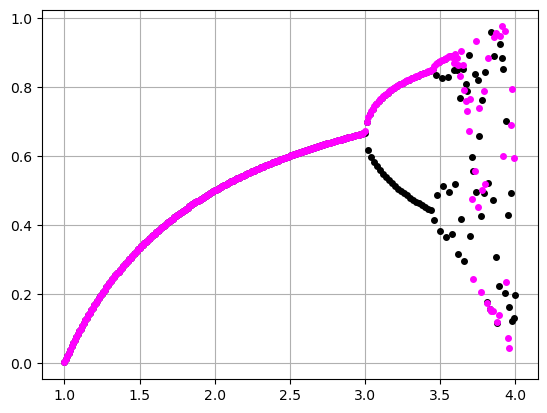

In [54]:
plt.plot(Tasa,Convergencia, 'ko', ms = 4)
plt.plot(r,x, 'o', ms = 4, color = "magenta")
plt.grid()
plt.show()

ha diferencia del primer codigo y grafica color negro, para la segunda grafica, solo obtenemos un lado de la birfucación para la misma cantidad de iteraciones, y a pesar ser la misma ecuación el ejecutar este proceso con arreglos, tenemos diferentes errores de cálculo por parte del programa. 
Lo cual genera que despues de la bufurcación tengamos valores muy variados que no coinciden con los negros.

## Ejercicio 3: El conjunto de Mandelbrot

a) Escribe un programa para crear una imagen del conjunto de Mandelbrot realizando la iteracion para todos los valores de  ́ c = x + iy en una cuadr ́ıcula de N × N que abarque la region donde  ́ −2 ≤ x ≤ 2 y −2 ≤ y ≤ 2. Haz una grafica  de densidad (density plot) en el que los puntos de la cuadr ́ıcula dentro del conjunto de Mandelbrot esten coloreados en negro y los de afuera esten coloreados en  blanco.

In [55]:
N = 100 #número de iteraciones
a = 3000 #definición del conjunto
x= np.linspace(-2,2,a) #arreglo de x
y = np.linspace(-2,2,a) #arreglo de y
M = np.zeros((a,a)) #matriz de 0 de a*a 
for j in range(len(x)):#fijamos una j de la longitud de x
    for k in range(len(y)): #fijamos una k de la longitud de y
        Mandelbrot = True #creamos un booleano que si mandelbrot es verdadero significa, está en el conjunto de mandelbrot
        zn = 0 +0j #definimos nuestra variable inicial
        c = complex(x[j],y[k]) #definimos el complejo c como x+iy
        #zn = zn**2 + c #ejecutamos por primera vez la fórmula
        for i in range (N):
            if Mandelbrot == True:#si esta en el conjunto de mandelbrot de iteración i,
                zn = zn**2 + c #aplicamos la formula
                modulo = abs(zn) #obtenemos el modulo de zn
                if modulo <= 2: #si menor o igual a 2, el for continua iterando
                    continue
                else: #si no lo es, entonces cambia la condición del booleano
                    Mandelbrot = False
            elif Mandelbrot == False: #cuando ejecute la iteración y si zn ya no esta en mandelbrot por lo tanto c, no lo está
                M[k][j] = 1 #cambia el valor de mi casilla a 1
                break #lo quiebra y regresa al for de las k.


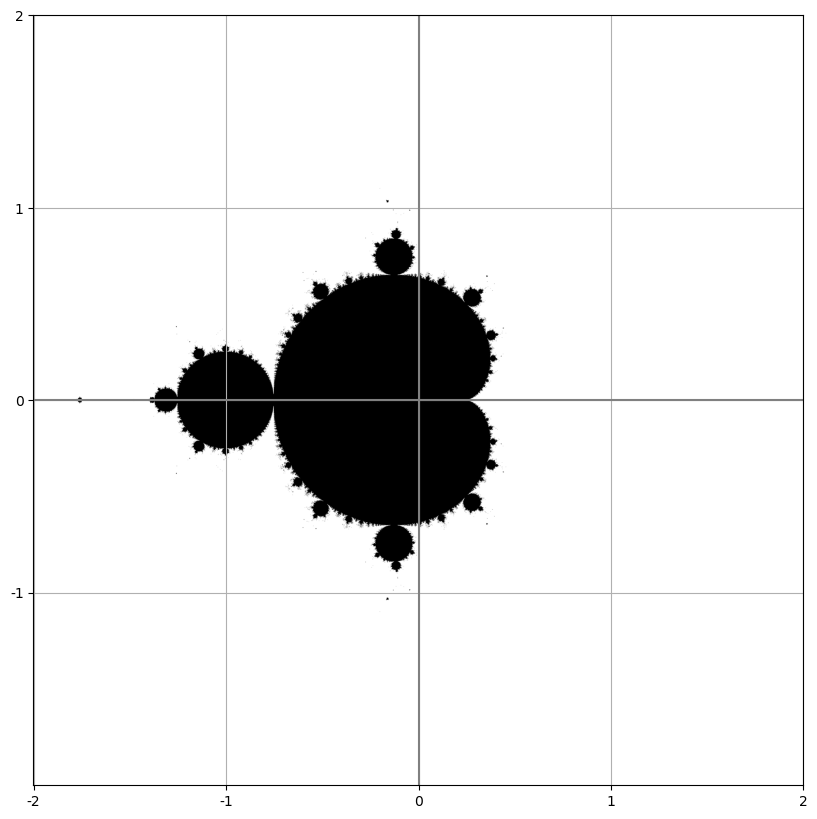

In [56]:
from pylab import imshow,gray,show
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.xticks([0,len(M)/4,len(M)/2, 3*len(M)/4 ,len(M)-1],[-2,-1,0,1,2])
plt.yticks([0,len(M)/4,len(M)/2, 3*len(M)/4 ,len(M)],[2,1,0,-1,-2])
plt.axvline(x=len(M)/2 , color = "gray")
plt.axhline(y=len(M)/2 , color = "gray")
plt.grid()
imshow(M) 
plt.gray()

** Opcional (para 1.5 puntos extra): Si te aburrio lo anterior (o te resulto demasiado facil), puedes programar otra variante del mismo ejercicio que puede producir imagenes sorprendentes. En lugar de colorear los puntos solo en blanco o negro, colorea los puntos de acuerdo con el numero de iteraciones de la ecuacion antes de que |zn| sea mayor que 2 (o bien el numero m  ́ aximo de iteraciones si es que |zn| nunca llega a ser mayor que 2). Si usas alguno de los esquemas mas coloridos que Python proporciona para las graficas de densidad, como “ hot” or “jet”, puedes crear algunas imagenes muy espectaculares. Otra variante interesante es colorear segun el logaritmo del numero de iteraciones, lo que ayuda a revelar parte de la estructura mas fina fuera del conjunto.

In [57]:
def mandelbrot(N):
    a = 3000 #definición del conjunto
    x= np.linspace(-2,2,a)
    y = np.linspace(-2,2,a)
    M = np.zeros((a,a))
    for j in range(len(x)):
        for k in range(len(y)):
            Mandelbrot = True
            zn = 0 +0j
            c = complex(x[j],y[k])
            for i in range (N):
                if Mandelbrot == True:
                    zn = zn**2 + c
                    modulo = abs(zn)
                    if modulo <= 2:
                        continue
                    else:
                        Mandelbrot = False
                elif Mandelbrot == False:
                    M[k][j]=modulo #modificación al primer codigo, es que veremos como cambia acorde a como el módulo es diferente, tendremos formas de figuras acorde a como dejan de pertenecer al conjunto de mandelbrot.
                    break
    return M

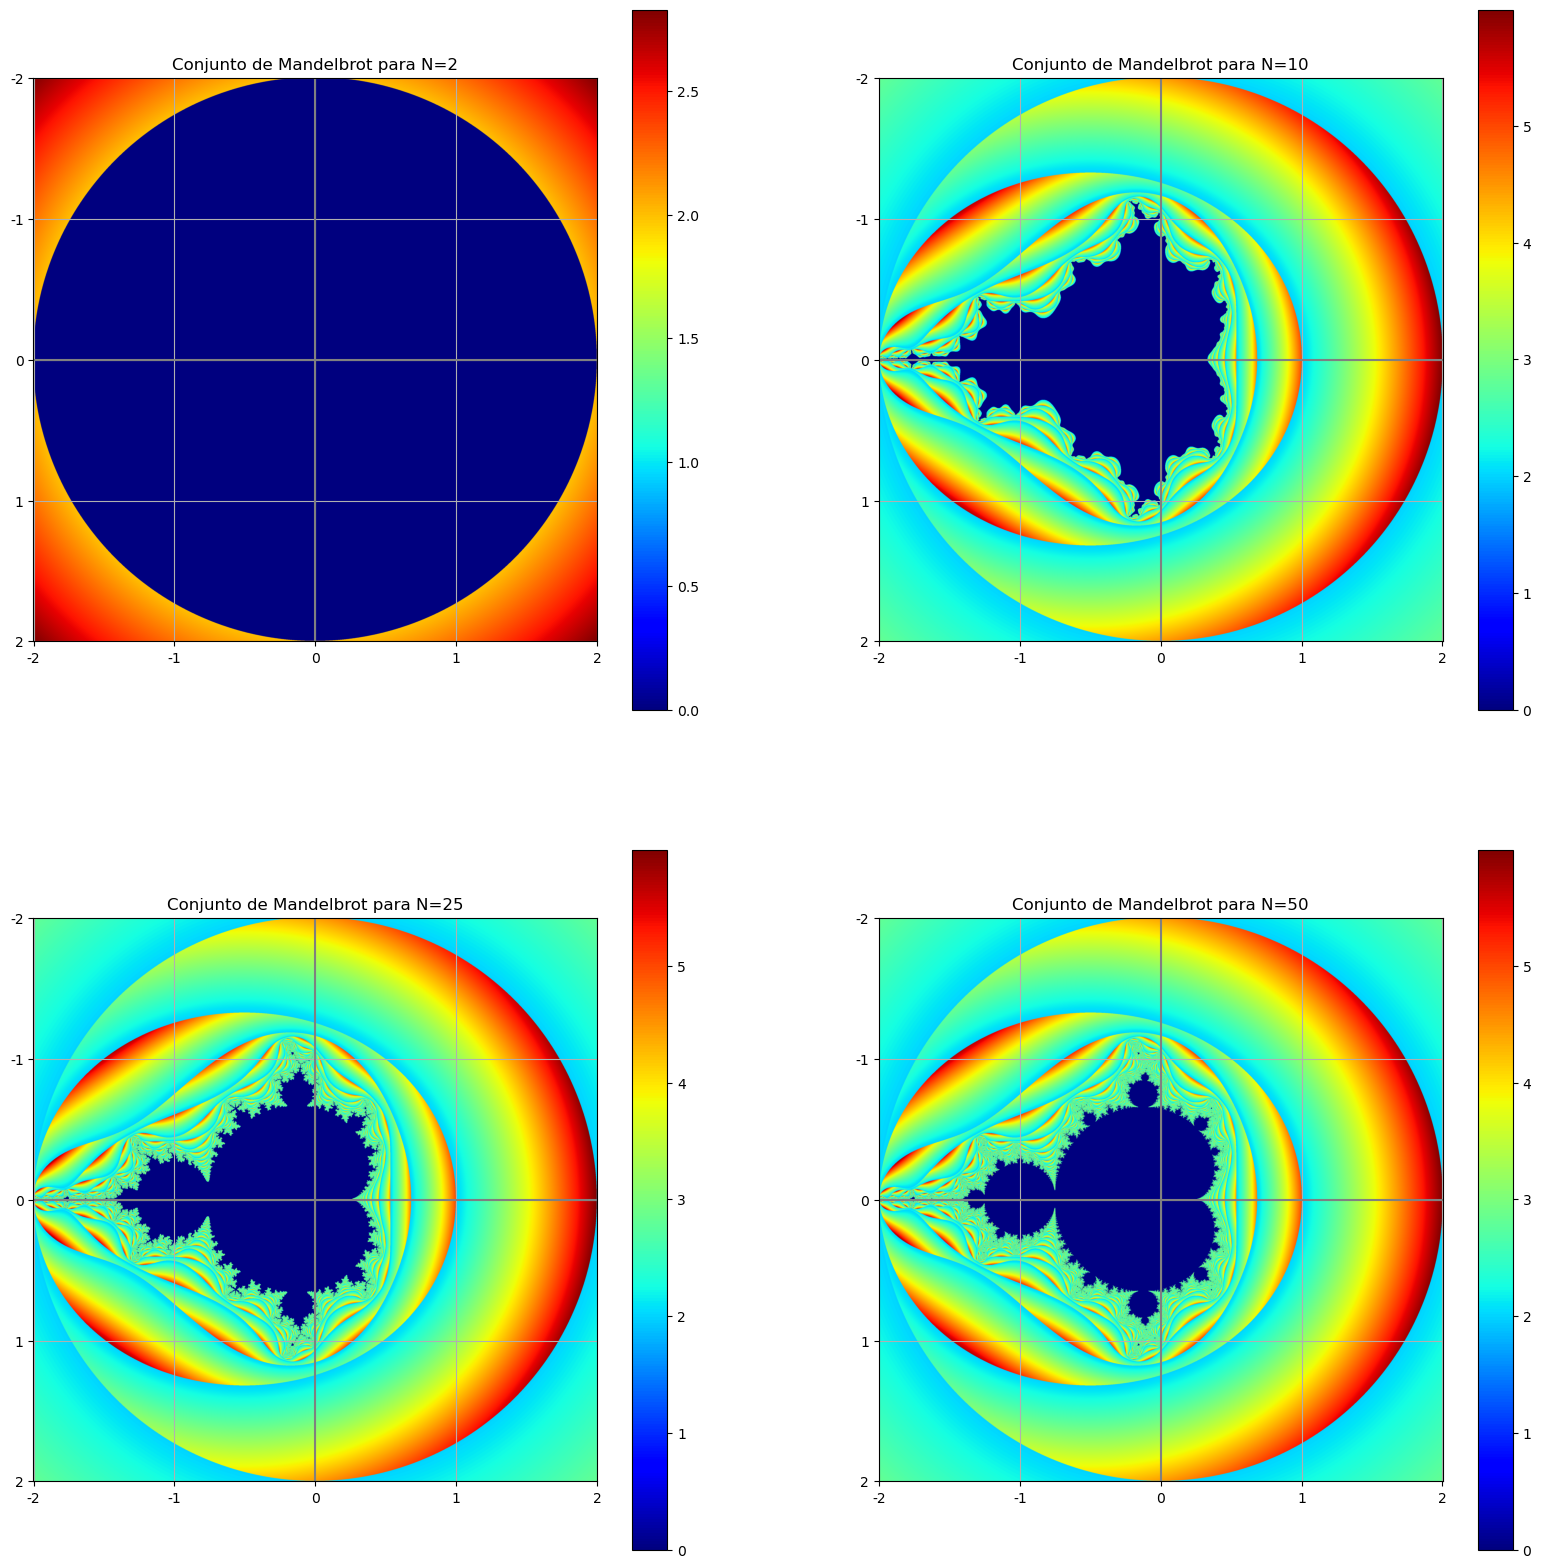

In [62]:
plt.figure(figsize=(20,20))
#especificaciones generales, para apreciar estos cambios graficamos 4 conjuntos de mandelbrot a diferentes iteraciones N, creando los subplots y con mapas de coleres
#como se trata de una matriz las xticks & yticks nos ayudan a cambiar las etiquetas de los bordes


plt.subplot(221)
plt.title('Conjunto de Mandelbrot para N=2')
M1 = mandelbrot(2)
plt.xticks([0,len(M1)/4,len(M1)/2, 3*len(M1)/4 ,len(M1)-1],[-2,-1,0,1,2])
plt.yticks([0,len(M1)/4,len(M1)/2, 3*len(M1)/4 ,len(M1)-1],[-2,-1,0,1,2])
plt.axvline(x=len(M1)/2 , color = "gray")
plt.axhline(y=len(M1)/2 , color = "gray")
plt.grid()
imshow(M1, cmap = 'jet') 
plt.colorbar()


plt.subplot(222)
plt.title('Conjunto de Mandelbrot para N=10')
M2 = mandelbrot(10)
plt.xticks([0,len(M2)/4,len(M2)/2, 3*len(M2)/4 ,len(M2)-1],[-2,-1,0,1,2])
plt.yticks([0,len(M2)/4,len(M2)/2, 3*len(M2)/4 ,len(M2)-1],[-2,-1,0,1,2])
plt.axvline(x=len(M2)/2 , color = "gray")
plt.axhline(y=len(M2)/2 , color = "gray")
plt.grid()
imshow(M2, cmap = 'jet') 
plt.colorbar()

plt.subplot(223)
plt.title('Conjunto de Mandelbrot para N=25')
M3 = mandelbrot(25)
plt.xticks([0,len(M3)/4,len(M3)/2, 3*len(M3)/4 ,len(M3)-1],[-2,-1,0,1,2])
plt.yticks([0,len(M3)/4,len(M3)/2, 3*len(M3)/4 ,len(M3)-1],[-2,-1,0,1,2])
plt.axvline(x=len(M3)/2 , color = "gray")
plt.axhline(y=len(M3)/2 , color = "gray")
plt.grid()
imshow(M3, cmap = 'jet') 
plt.colorbar()

plt.subplot(224)
plt.title('Conjunto de Mandelbrot para N=50')
M4 = mandelbrot(50)
plt.xticks([0,len(M4)/4,len(M4)/2, 3*len(M4)/4 ,len(M4)-1],[-2,-1,0,1,2])
plt.yticks([0,len(M4)/4,len(M4)/2, 3*len(M4)/4 ,len(M4)-1],[-2,-1,0,1,2])
plt.axvline(x=len(M4)/2 , color = "gray")
plt.axhline(y=len(M4)/2 , color = "gray")
plt.grid()
imshow(M4, cmap = 'jet') 
plt.colorbar()

#se tarda 2 minutos pero vale la pena